# Ontologies creation using NAIVE approaches

This notebook explores an initial approach to the challenge of ontology creation using large language models (LLMs). We will follow a simple heuristic to generate results and evaluate output:

1. **Input:** We start by providing a domain name and 5-10 terms related to the domain from which we wish to generate an ontology. This will expand to include a domain and topic, a definition for both, and eventually additional initial terms.
   
2. Given the input, we will request a large language model (in this case, ChatGPT-4o) to return a number (to be defined) of related terms.
   
3. Following initial thesis on calculation of semantic distance, we will request the model to calculate distance between terms. We will then test by removing or not removing terms with the lowest semantic distance and by requesting step 2 multiple times (distill).
   
4. Given the output of step 3, we will cluster results using hierarchical clustering.
   
5. Clusters will be used to serialize as RDF with a predicate "as-is" and the terms internally with "is-related". At this stage, we will also test requesting an LLM to generate text using the given terms and the domain/topic to test the extraction of different relations.
   
6. We will plot the ontology.
   
7. Compare the output with similar results from dbpedia.org.


### Prompts used for semantic distance calculations

Based out of initial work we will use the following prompts which have be shown to return good results. For this initial experiment we will only use english prompts to isolate tasks. we don't wish to analyse model capacity for task execution on a multi language environment.

```txt
In this survey you’ll be asked to rate quantitatively, on a scale, the intensity of the semantic relatedness between pairs of affective words. Please, before starting, read carefully the instructions and the examples provided. 

The question we’re asking is: how much related are the two words? Vaguely related words should be scored with lower values, and strongly related words with higher values. Please note that opposite words frequently present high values of relatedness.

For example, the words ’modest’ and ’smart’ don’t seem very related. ’Conceal’ and ’mask’ seem very related. ’Confident’ is highly related with itself. ’Violent’ and ’pacific’, being opposite words, are frequently related, just like ’happiness’ and ’sadness’. 

Examples: 
* modest, smart: 1,
* conceal, mask: 4 
* confident, confident: 5 
* violent, pacific: 4 
* happiness, sadness: 5

Please rate from 0 to 4 the semantic relatedness of the following pairs of words, with 0 indicating words not related at all and 4 indicating very related words: 
apple, galaxy
fault, system
champion, winner 
town, city

```

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
import json
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src.services import ChatGpt
from src.services import clustering
from src.services import Ontology

---

## Experiment 2: 

**Description:** 

1. use a domain name and 20 terms related and request a term cloud. 
2. Request semantic distance between terms
3. Detil: remove clusters of just one element. Restart process with remaining terms once
4. Run hierarchy cluster
5. serialize into rdf

In [2]:
agent = ChatGpt()
agent.model = "gpt-4o-mini"

In [7]:
terms_list_str = agent.chat(
    instructions="You are a taxonomy and ontology expert. Provide concise and accurate responses based on the user's queries.",
    input="""
        Provide a list of 20 categories, terms or words closely related to domain or topic and using the provided terms as reference.
        
        - the domain or topic is: cinema
        - the provided terms are: 
            start trek, spoke, vulcan, klingon, enterprise
        
        Your output should be a json array with only the category names, without any additional text. 
        This categories should include the given terms and be closely related to the domain or topic.
        Do not encapsulate the output in code blocks.
        
        Example output:
        [
            "category1",
            "category2",
            ...            "category100"
        ]
        
    """
)

In [8]:
# Clean output. 
terms_list_json = json.loads(terms_list_str)
terms_list_df = pd.DataFrame(terms_list_json, columns=["category"])
print(terms_list_df.head(10))
print(terms_list_df.tail(10))

     category
0   Star Trek
1       Spock
2      Vulcan
3     Klingon
4  Enterprise
5      Sci-Fi
6    Starship
7  Federation
8        Borg
9  Warp Drive
               category
10          Time Travel
11        Alien Species
12             Holodeck
13            Starfleet
14               Phaser
15            Tricorder
16              Romulan
17          Transporter
18              Captain
19  Interstellar Travel


In [9]:
# Cartesian product with provided terms
terms_pair = pd.merge(terms_list_df, terms_list_df, how='cross')
terms_pair = terms_pair.drop(terms_pair[terms_pair['category_x'] == terms_pair['category_y']].index) # We don't need to analyse a term with itself

In [10]:
## Calculate similarity for each pair
similarity_df = agent.get_similarity(terms_pair)

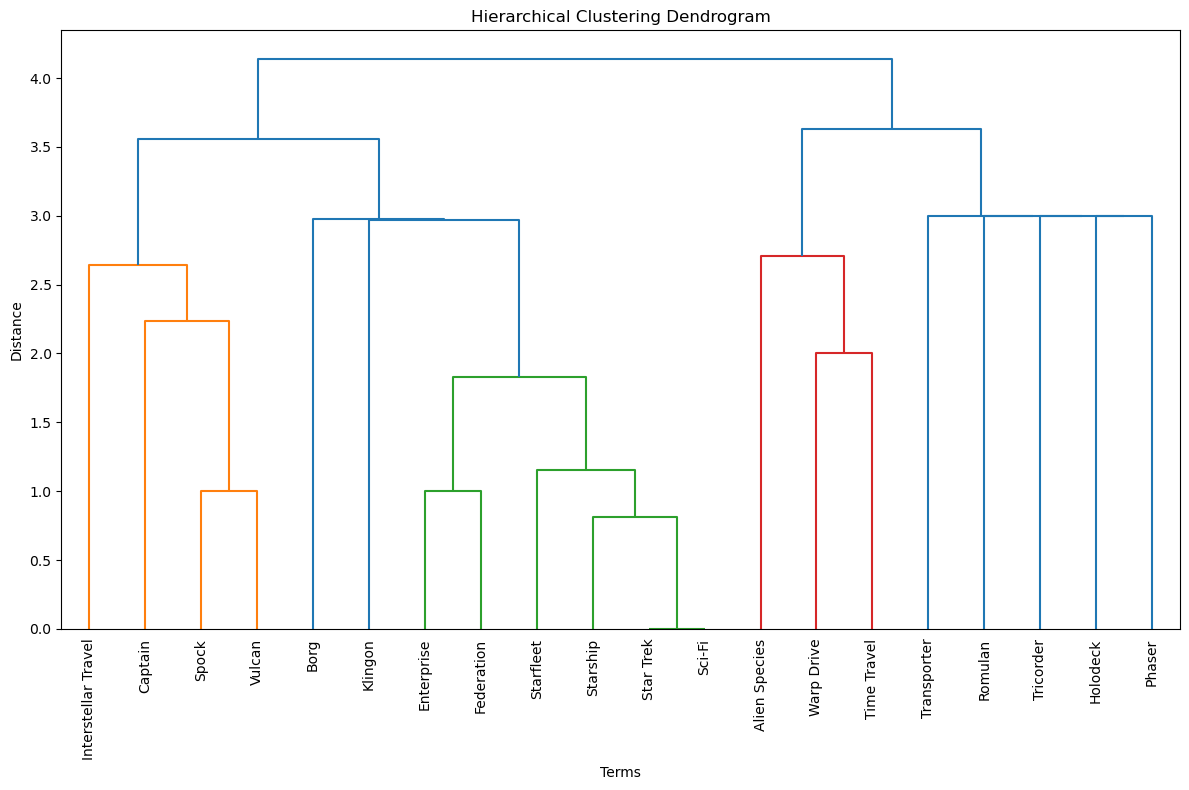

In [11]:
terms, distance_matrix, condensed_dist = clustering.create_distance_matrix(similarity_df, max_similarity = 5)

Z = linkage(condensed_dist, metric='euclidean', method="ward")

plt.figure(figsize=(12, 8))
dendrogram(Z, labels=terms, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Terms')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [14]:
# Extract clusters
distance_threshold = 1 # similar to a 3
clusters = fcluster(Z, t=distance_threshold, criterion='distance')
cluster_df = pd.DataFrame({
    'term': terms,
    'cluster': clusters
})

cluster_sizes = cluster_df['cluster'].value_counts()
clusters_to_keep = cluster_sizes[cluster_sizes > 1].index
cluster_df = cluster_df[cluster_df['cluster'].isin(clusters_to_keep)]

cluster_df

,term,cluster
0,Star Trek,5
1,Spock,1
2,Vulcan,1
4,Enterprise,4
5,Sci-Fi,5
6,Starship,5
7,Federation,4


In [17]:
additional_terms = cluster_df['term'].unique().tolist()
print(additional_terms)

['Star Trek', 'Spock', 'Vulcan', 'Enterprise', 'Sci-Fi', 'Starship', 'Federation']


In [19]:
# starting second run providing the output as context

terms_list_str_additional = agent.chat(
    instructions="You are a taxonomy and ontology expert. Provide concise and accurate responses based on the user's queries.",
    input=f"""
        Provide a list of 20 categories, terms or words closely related to domain or topic and using the provided terms as reference.
        
        - the domain or topic is: cinema
        - the provided terms are: 
            start trek, spoke, vulcan, klingon, enterprise, {', '.join(additional_terms)}]
        
        Your output should be a json array with only the category names, without any additional text. 
        This categories should include the given terms and be closely related to the domain or topic.
        Do not encapsulate the output in code blocks.
        
        Example output:
        [
            "category1",
            "category2",
            ...            "category100"
        ]
        
    """
)

In [21]:
# Clean output. 
terms_list_json_additional = json.loads(terms_list_str_additional)
terms_list_df_additional = pd.DataFrame(terms_list_json_additional, columns=["category"])
combined_df = pd.concat([terms_list_df, terms_list_df_additional], ignore_index=True)
combined_df = combined_df.drop_duplicates(subset=['category'])
terms_pair_add = pd.merge(combined_df, combined_df, how='cross')
terms_pair_add = terms_pair_add.drop(terms_pair_add[terms_pair_add['category_x'] == terms_pair_add['category_y']].index)


In [22]:
print(terms_pair_add )

                 category_x          category_y
1                 Star Trek               Spock
2                 Star Trek              Vulcan
3                 Star Trek             Klingon
4                 Star Trek          Enterprise
5                 Star Trek              Sci-Fi
...                     ...                 ...
1150  Character Development     Klingon Culture
1151  Character Development     Starship Design
1152  Character Development           Telepathy
1153  Character Development  Robotics in Sci-Fi
1154  Character Development      Hero's Journey

[1122 rows x 2 columns]


In [23]:
similarity_df = agent.get_similarity(terms_pair_add)

JSONDecodeError: Unterminated string starting at: line 834 column 52 (char 62830)

In [ ]:
similarity_df['category_x'].unique()

In [ ]:
terms, distance_matrix, condensed_dist = clustering.create_distance_matrix(similarity_df, max_similarity = 5)

Z = linkage(condensed_dist, metric='euclidean', method="ward")

plt.figure(figsize=(12, 8))
dendrogram(Z, labels=terms, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Terms')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [ ]:
# Extract clusters
distance_threshold = 1 # similar to a 3
clusters = fcluster(Z, t=distance_threshold, criterion='distance')
print(clusters)

In [ ]:
cluster_df = pd.DataFrame({
    'term': terms,
    'cluster': clusters
})

cluster_df

In [ ]:
cluster_names = cluster_df.groupby('cluster')['term'].apply(agent.generate_cluster_name)
cluster_df['cluster_name'] = cluster_df['cluster'].map(cluster_names)
cluster_df

In [ ]:
ontology = Ontology()
ontology.build_ontology(cluster_df)
ontology.serialize_ontology(format='turtle')

print(ontology.turtle)

In [ ]:
ontology.visualize()